# Arabic Dialect Classification

This project aims to classify Arabic text into dialect categories using both traditional machine learning and deep learning approaches.

The focus of this notebook is binary classification between:
- Khaleeji
- Masri

We compare:
- Logistic Regression with TF-IDF
- LSTM with tokenized sequences


## Problem Statement

Arabic has many dialects that differ across regions. These dialectal differences make automatic dialect identification a challenging Natural Language Processing task.

The goal of this project is to build models that can classify Arabic text into its corresponding dialect based on linguistic patterns in the text.

## Objectives

- Load and prepare an Arabic dialect dataset
- Filter the dataset for selected dialects
- Clean and preprocess Arabic text
- Train a machine learning model using TF-IDF
- Train a deep learning model using LSTM
- Compare the performance of both approaches

##libraries

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

## Load Dataset
We load the Arabic dialect dataset and convert it into a pandas DataFrame for easier processing.

In [2]:
dataset = load_dataset("dataflare/arabic-dialect-corpus")
df = pd.DataFrame(dataset["train"])

df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/26.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211593 [00:00<?, ? examples/s]

,text,utterance_type,dialect,tokens
0,دقيقه في كثير من البلاغات,Statement,Khaleeji,16
1,انا الحين اوصل في 10 15 20 دقيقه عشان,Statement,Khaleeji,25
2,اوصل المستشفى 40 دقيقه ليش؟ هذا سقراط من ثماني...,Question,Khaleeji,48
3,استضيف قاده التحول وقاده الاعمال وقاده الراي ض...,Question,Khaleeji,49
4,جلال العويسه رئيس هيئه الهلال الاحمر السعودي ح...,Question,Khaleeji,48


## Dataset Overview
We keep only the relevant columns needed for this task:
- `text`: the Arabic sentence
- `dialect`: the dialect label

In [3]:
df = df[["text", "dialect"]].dropna().copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (211593, 2)


,text,dialect
0,دقيقه في كثير من البلاغات,Khaleeji
1,انا الحين اوصل في 10 15 20 دقيقه عشان,Khaleeji
2,اوصل المستشفى 40 دقيقه ليش؟ هذا سقراط من ثماني...,Khaleeji
3,استضيف قاده التحول وقاده الاعمال وقاده الراي ض...,Khaleeji
4,جلال العويسه رئيس هيئه الهلال الاحمر السعودي ح...,Khaleeji


In [4]:
df["dialect"].value_counts()

,count
dialect,
Khaleeji,114116
Masri,90166
Iraqi,4769
Levantine,2025
Maghrebi,319
Yemeni,179
Sudanese,19


## Initial Dialect Distribution
This plot shows the class distribution before filtering the dataset.

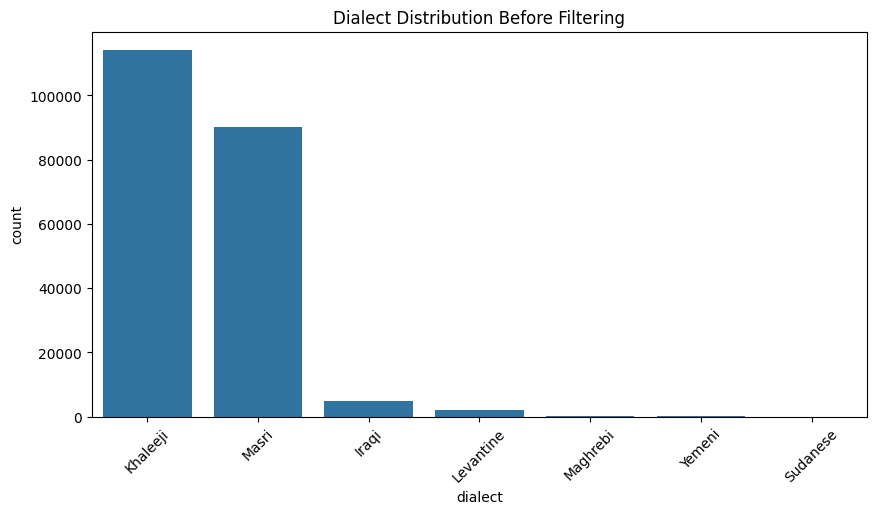

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(x="dialect", data=df, order=df["dialect"].value_counts().index)
plt.title("Dialect Distribution Before Filtering")
plt.xticks(rotation=45)
plt.show()

## Select Target Dialects
For this experiment, we focus on binary classification between:
- Khaleeji
- Masri

In [6]:
selected_dialects = ["Khaleeji", "Masri"]
df = df[df["dialect"].isin(selected_dialects)].copy()

df["dialect"].value_counts()

,count
dialect,
Khaleeji,114116
Masri,90166


## Balance the Dataset
To avoid bias toward one class, we balance the dataset by sampling the same number of examples from each dialect.

In [7]:
min_samples = df["dialect"].value_counts().min()

df = (
    df.groupby("dialect", group_keys=False)
      .apply(lambda x: x.sample(min_samples, random_state=42))
      .reset_index(drop=True)
)

df["dialect"].value_counts()

/tmp/ipykernel_7428/3925573033.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_samples, random_state=42))


,count
dialect,
Khaleeji,90166
Masri,90166


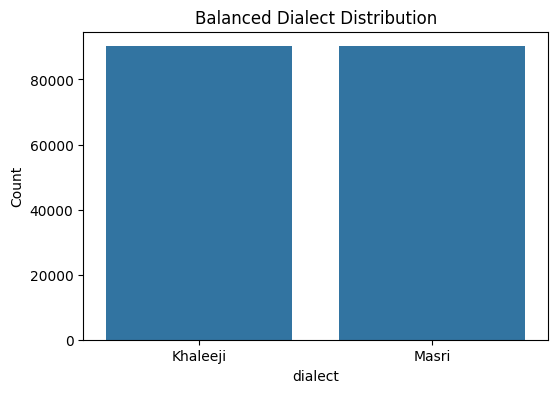

In [8]:
plt.figure(figsize=(6, 4))
counts = df["dialect"].value_counts()
sns.barplot(x=counts.index, y=counts.values)
plt.title("Balanced Dialect Distribution")
plt.ylabel("Count")
plt.show()

## Text Cleaning
Arabic text may contain punctuation, digits, and extra spaces.  
We apply basic preprocessing to standardize the text before training.

In [9]:
def clean_text(text):
    text = str(text)

    text = re.sub(r"[^\w\s\u0600-\u06FF]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r"[؟،؛!.,]", "", text)
    return text

## Cleaned Text Example

Below is a comparison between the original text and the cleaned version after preprocessing.

In [10]:
df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,يقول ابغى افتح صفحه مع المملكه العربيه السعودي...,يقول ابغي افتح صفحه مع المملكه العربيه السعودي...
1,تقدر تطلع كل الاسطول والعدد بينه وبينك تتكلم ع...,تقدر تطلع كل الاسطول والعدد بينه وبينك تتكلم ع...
2,والاديان ليست سوى انعكاس لرغبات بشريه متغيره و...,والاديان ليست سوي انعكاس لرغبات بشريه متغيره و...
3,الرفض هو اللي قاعد يولد هذا الشعور؟ هل اللي قا...,الرفض هو اللي قاعد يولد هذا الشعور هل اللي قاع...
4,الدوله بتحمل جزء من التكلفه انه موظفينك بتوظفه...,الدوله بتحمل جزء من التكلفه انه موظفينك بتوظفه...


Note:
I intentionally avoid aggressive text cleaning to preserve dialect-specific features, which are essential for accurate classification.

## Prepare Features and Labels
We use the cleaned text as input and the dialect labels as targets.

In [11]:
X = df["clean_text"]
y = df["dialect"]

## Train-Test Split
i split the dataset into training and testing sets while preserving class balance using stratification.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 144265
Testing samples: 36067


## Encode Labels
The dialect labels are converted into numeric values for model training.

In [13]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

print("Classes:", list(encoder.classes_))

Classes: ['Khaleeji', 'Masri']


## Model 1: Logistic Regression with TF-IDF
First, we train a traditional machine learning baseline using TF-IDF features and Logistic Regression.

In [14]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=8000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_tfidf, y_train_enc)

pred_lr = lr.predict(X_test_tfidf)

## Logistic Regression Evaluation
i evaluate the model using:
- Accuracy
- Classification report
- Confusion matrix

In [16]:
lr_accuracy = accuracy_score(y_test_enc, pred_lr)
print("Logistic Regression Accuracy:", lr_accuracy)
print()
print(classification_report(y_test_enc, pred_lr, target_names=encoder.classes_))

Logistic Regression Accuracy: 0.8823578340311088

              precision    recall  f1-score   support

    Khaleeji       0.87      0.90      0.88     18034
       Masri       0.89      0.87      0.88     18033

    accuracy                           0.88     36067
   macro avg       0.88      0.88      0.88     36067
weighted avg       0.88      0.88      0.88     36067



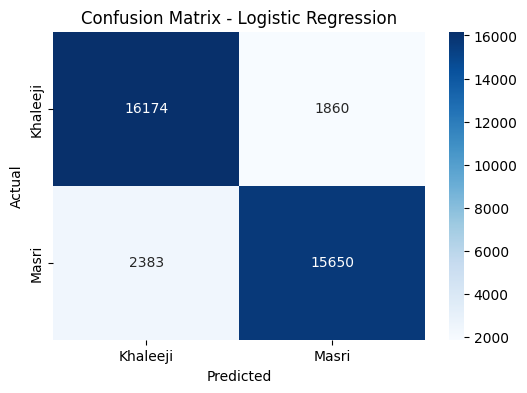

In [17]:
cm_lr = confusion_matrix(y_test_enc, pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model 2: LSTM
Next, i train a deep learning model using tokenized and padded text sequences.

In [18]:
tokenizer = Tokenizer(num_words=30000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=120)
X_test_pad = pad_sequences(X_test_seq, maxlen=120)

In [19]:
model = Sequential([
    Embedding(input_dim=30000, output_dim=128, input_length=120),
    LSTM(128),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the LSTM Model
i train the LSTM model and monitor validation performance.

In [20]:
history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/5
2029/2029 ━━━━━━━━━━━━━━━━━━━━ 30s 12ms/step - accuracy: 0.8946 - loss: 0.2549 - val_accuracy: 0.9297 - val_loss: 0.1842
Epoch 2/5
2029/2029 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.9562 - loss: 0.1255 - val_accuracy: 0.9371 - val_loss: 0.1737
Epoch 3/5
2029/2029 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9728 - loss: 0.0809 - val_accuracy: 0.9353 - val_loss: 0.2066
Epoch 4/5
2029/2029 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9831 - loss: 0.0516 - val_accuracy: 0.9333 - val_loss: 0.2383
Epoch 5/5
2029/2029 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9898 - loss: 0.0317 - val_accuracy: 0.9317 - val_loss: 0.2756


In [21]:
loss, lstm_accuracy = model.evaluate(X_test_pad, y_test_enc, verbose=0)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.932625412940979


## Compare Model Performance
We compare the final test accuracy of both models.

In [22]:
results = {
    "Logistic Regression (TF-IDF)": lr_accuracy,
    "LSTM": lstm_accuracy
}

results_df = pd.DataFrame.from_dict(results, orient="index", columns=["Accuracy"])
results_df

,Accuracy
Logistic Regression (TF-IDF),0.882358
LSTM,0.932625


## Model Comparison

The LSTM model outperformed Logistic Regression (TF-IDF).

- Logistic Regression Accuracy: 88.2%
- LSTM Accuracy: 93.3%

The improvement shows that LSTM captures contextual patterns more effectively.

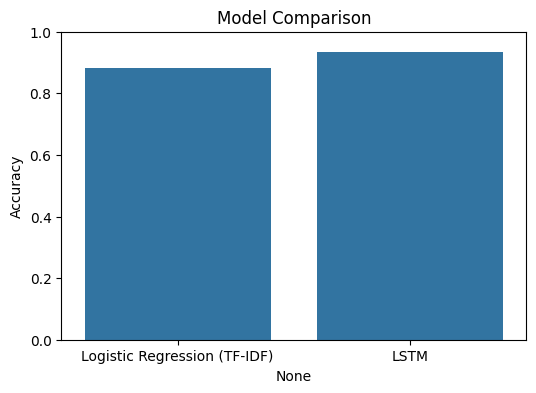

In [23]:
plt.figure(figsize=(6, 4))
sns.barplot(x=results_df.index, y=results_df["Accuracy"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

## Test on Custom Samples
Finally, i test the trained models on manually written Arabic samples.

In [24]:
samples = [
    "وش أخبارك اليوم؟",
    "إزيك عامل ايه؟",
    "شلونك شخبارك؟",
    "حاسب يا أسطى",
    "انت بتعمل ايه؟",
    "رحت لدوامك اليوم؟",
    "عايز آكل حاجة على الماشي",
    "قشطه يا معلم",
    "سلام عليكم",
    "يا ابني انت مسطول ولا ايه",
    "وش مشكلتك انت",
    "استح على وجهك",
    "استح على دمك",
    "عايز أشتري عربية جديدة",
    "أبغى أشتري سيارة جديدة",
    "رايح فين دلوقتي؟",
    "وين رايح الحين؟",
    "ما عليه، تصير خير",
    "الموضوع ده بسيط خالص",
    "شنو رايك في الموضوع؟"
]

clean_samples = [clean_text(text) for text in samples]

In [25]:
sample_tfidf = tfidf.transform(clean_samples)
sample_preds_lr = lr.predict(sample_tfidf)
sample_labels_lr = encoder.inverse_transform(sample_preds_lr)

pd.DataFrame({
    "Text": samples,
    "Predicted Dialect (LR)": sample_labels_lr
})

,Text,Predicted Dialect (LR)
0,وش أخبارك اليوم؟,Khaleeji
1,إزيك عامل ايه؟,Masri
2,شلونك شخبارك؟,Khaleeji
3,حاسب يا أسطى,Khaleeji
4,انت بتعمل ايه؟,Masri
5,رحت لدوامك اليوم؟,Khaleeji
6,عايز آكل حاجة على الماشي,Masri
7,قشطه يا معلم,Khaleeji
8,سلام عليكم,Khaleeji
9,يا ابني انت مسطول ولا ايه,Masri


In [26]:
sample_seq = tokenizer.texts_to_sequences(clean_samples)
sample_pad = pad_sequences(sample_seq, maxlen=120)

sample_preds_lstm = (model.predict(sample_pad) > 0.5).astype("int32").flatten()
sample_labels_lstm = encoder.inverse_transform(sample_preds_lstm)

pd.DataFrame({
    "Text": samples,
    "Predicted Dialect (LR)": sample_labels_lr,
    "Predicted Dialect (LSTM)": sample_labels_lstm
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


,Text,Predicted Dialect (LR),Predicted Dialect (LSTM)
0,وش أخبارك اليوم؟,Khaleeji,Khaleeji
1,إزيك عامل ايه؟,Masri,Masri
2,شلونك شخبارك؟,Khaleeji,Khaleeji
3,حاسب يا أسطى,Khaleeji,Masri
4,انت بتعمل ايه؟,Masri,Masri
5,رحت لدوامك اليوم؟,Khaleeji,Khaleeji
6,عايز آكل حاجة على الماشي,Masri,Masri
7,قشطه يا معلم,Khaleeji,Masri
8,سلام عليكم,Khaleeji,Khaleeji
9,يا ابني انت مسطول ولا ايه,Masri,Masri


The LSTM model performs better on context-dependent expressions, while Logistic Regression struggles with phrases that require understanding of dialect-specific usage.

## Conclusion

In this project, I built and evaluated two approaches for Arabic dialect classification: Logistic Regression with TF-IDF and an LSTM-based model.

The results show that the LSTM model outperformed Logistic Regression on the test set, achieving higher accuracy (93.3% vs 88.2%). This indicates that LSTM is more effective at capturing contextual and sequential patterns in Arabic text.

Through this project, I found that:
- Text preprocessing plays an important role, but should be kept minimal for dialect tasks
- Traditional models perform well on surface-level patterns
- Deep learning models can better capture context-dependent expressions

Overall, this project demonstrates how different modeling approaches impact performance in Arabic NLP tasks, and highlights the importance of choosing the right model for the problem.

## Future Work

To further improve this project, I plan to extend both the data and modeling approaches.

Future enhancements include:
- Expanding the classification task to multiple Arabic dialects
- Improving Arabic text normalization and preprocessing techniques
- Applying advanced deep learning models such as transformer-based architectures (e.g., AraBERT)
- Performing systematic hyperparameter tuning for both models
- Deploying the model as a simple web application

### Notes

This project was developed as an individual effort to explore Arabic dialect classification using both traditional machine learning and deep learning approaches.